In [2]:
import os
import sys
import toto
# Add the project root to sys.path so 'data', 'inference', 'model' can be imported
project_root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'model_zoo', 'ToTo', 'toto'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    
import torch
from toto.data.util.dataset import MaskedTimeseries
from toto.inference.forecaster import TotoForecaster
from toto.model.toto import Toto

In [3]:
# Load the pre-trained model
toto = Toto.from_pretrained('Datadog/Toto-Open-Base-1.0')
toto.to('cuda')  # Move to GPU

# Optionally compile the model for faster inference
toto.compile()  # Uses Torch's JIT compilation for better performance

forecaster = TotoForecaster(toto.model)

torch.Size([1, 160])
Prediction error for training step train: 0.15


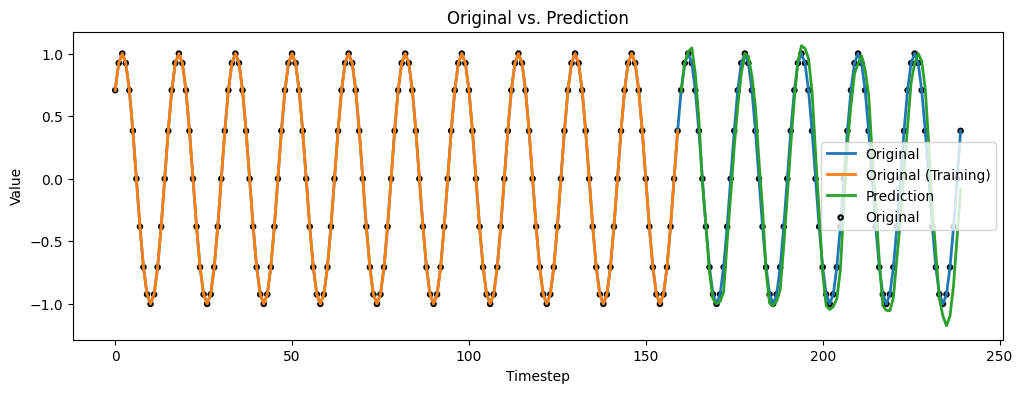

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Generate a periodic train of steps with at least 10 bumps
train_bumps = 10
period = 16
amplitude = 1.0
num_bumps = 15
pred_len = (num_bumps - train_bumps)* period


time_steps = num_bumps * period

# Create the step train with 10 bumps
def step_train(num_bumps, period, amplitude, time_steps):
    arr = np.zeros(time_steps)
    for i in range(num_bumps):
        pulse_length = period // 4 # + i * (period // (2 * num_bumps))
        start = i * period
        end = min(start + pulse_length, time_steps)
        arr[start:end] = amplitude

    return arr

def sinusoidal_train(num_bumps, period, amplitude, time_steps):
    arr = np.zeros(time_steps)
    for i in range(num_bumps):
        start = i * period
        end = min(start + period, time_steps)
        t = np.arange(0, end - start)  # Local time for the current bump
        freq = 1 #+ i * 0.2  # Frequency increases linearly with bump index
        arr[start:end] = amplitude * np.sin(2 * np.pi * freq * t / period + np.pi / 4)
    return arr

def smooth_increasing_freq_sin(n_cycles, start_period, amplitude, T):
    # Time vector
    t = np.linspace(0, 1, T)  # normalized time from 0 to 1
    
    # Final frequency to achieve n_cycles over total time
    # start_freq = 1 / start_period
    # Average freq = total_cycles / total_time = n_cycles / 1
    f0 = 1 / start_period
    f1 = 2 * n_cycles - f0  # because freq(t) = f0 + (f1 - f0) * t

    # Compute phase: integral of frequency over time
    freq_t = f0 + (f1 - f0) * t  # linearly increasing frequency
    phase = 2 * np.pi * np.cumsum(freq_t) / T  # integrate frequency to get phase

    # Generate sine wave
    y = amplitude * np.sin(phase)

    return y

# arr = smooth_increasing_freq_sin(num_bumps, period, amplitude, time_steps)
arr = sinusoidal_train(num_bumps, period, amplitude, time_steps)
train_steps = train_bumps * period

arr_train = arr[:train_steps]

# Create the shifted step train for training
shift = period // 4
shifted_arr_train = np.roll(arr_train, shift)

# Convert to PyTorch tensors and move to GPU
arr_tensor = torch.tensor(arr_train, dtype=torch.float32).unsqueeze(0).to('cuda')

print(arr_tensor.shape)

# Prepare inputs for the forecaster
inputs = MaskedTimeseries(
    series=arr_tensor,
    padding_mask=torch.full_like(arr_tensor, True, dtype=torch.bool),
    id_mask=torch.zeros_like(arr_tensor),
    timestamp_seconds=torch.ones_like(arr_tensor),
    time_interval_seconds=torch.full((1,), 60 * 15).to('cuda')
)

# Generate forecasts
forecast = forecaster.forecast(inputs, prediction_length=pred_len, num_samples=256, samples_per_batch=8)

# Compute prediction errors
error = torch.mean(
    torch.abs((forecast.median - arr_tensor[:, -pred_len:]) )
).item() # / (arr_tensor[:, -pred_len:] + epsilon)


print(f"Prediction error for training step train: {error:.2f}")

# Define time axis for training and validation
t_train = np.arange(len(arr_train))

pred = forecast.median[0, :].detach().cpu().numpy().squeeze()
t_pred = train_steps + np.arange(len(pred))

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(arr)), arr, label='Original', linewidth=2)
plt.plot(np.arange(len(arr_train)), arr_train, label='Original (Training)', linewidth=2)
plt.plot(t_pred, pred, label='Prediction', linewidth=2)
plt.scatter(np.arange(len(arr)), arr, label='Original', edgecolors='black', facecolors='none', s=10, linewidths=1.5)
plt.legend()
plt.title("Original vs. Prediction")
plt.xlabel("Timestep")
plt.ylabel("Value")
plt.show()


In [5]:
# !pip install relbench
from pyparsing import dbl_quoted_string
import relbench
from relbench.datasets import get_dataset_names, get_dataset
import pandas as pd

print(get_dataset_names())

dataset = get_dataset(name="rel-hm", download=True)
print(f"validation: {dataset.val_timestamp} - test: {dataset.test_timestamp}")
db = dataset.get_db(upto_test_timestamp=False)
print(f"training: {db.min_timestamp} - {db.max_timestamp}")
print(db.table_dict.keys())
table = db.table_dict["transactions"]

df = table.df.groupby(['t_dat', 'article_id']).sum('price')['price'].reset_index()
df = pd.pivot_table(df, index='t_dat', columns='article_id')['price'].reset_index()
df.columns.name = None
# display(df.head())

# Filter columns with non-NaN values of size 100 or greater
df = df.loc[:, df.notna().sum() >= 350]
display(df.head())
print(df.shape)
df.plot(x='t_dat', y=df.columns[1:10], kind='line', figsize=(12, 6))

ModuleNotFoundError: No module named 'relbench'

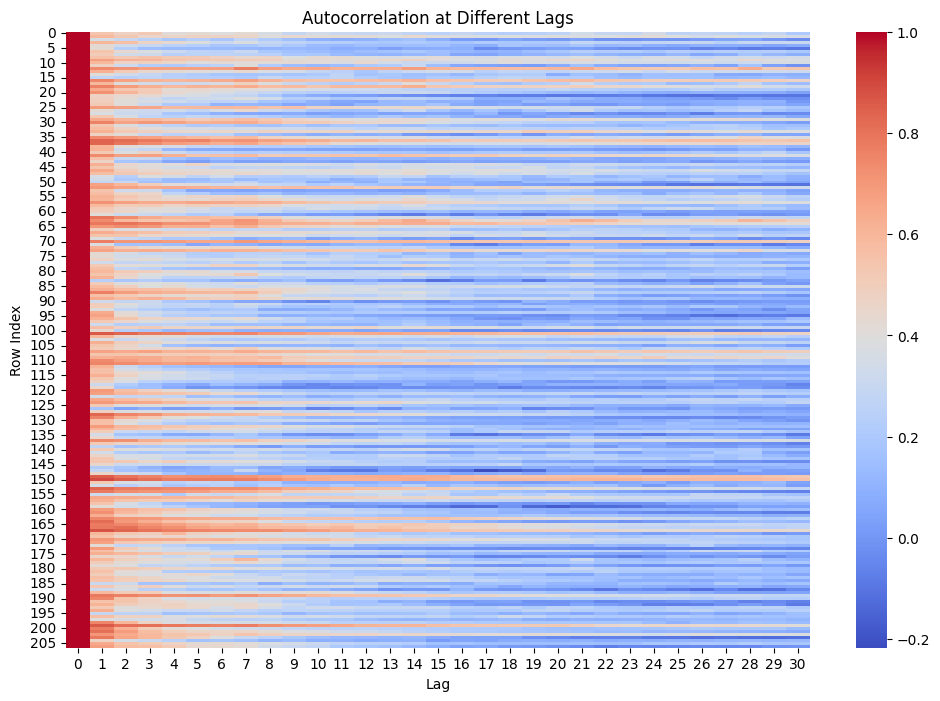

In [ ]:
from statsmodels.tsa.stattools import acf
import seaborn as sns

# Compute autocorrelation for each row at different lags
def compute_autocorrelation(df, max_lag=30):
    autocorr_matrix = np.zeros((df.shape[0], max_lag + 1))
    for i in range(df.shape[0]):
        row = df.iloc[i, :].dropna()
        autocorr_matrix[i, :] = acf(row, nlags=max_lag, fft=True)
    return autocorr_matrix

# Compute autocorrelation matrix
max_lag = 30
autocorr_matrix = compute_autocorrelation(df.drop(columns=['t_dat']).T, max_lag=max_lag)

# Plot the autocorrelation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(autocorr_matrix, annot=False, cmap='coolwarm', fmt='.2f', xticklabels=range(max_lag + 1))
plt.title("Autocorrelation at Different Lags")
plt.xlabel("Lag")
plt.ylabel("Row Index")
plt.show()


Training data shape: (366, 207)
Test data shape: (16, 207)
Prediction error for training step train: nan


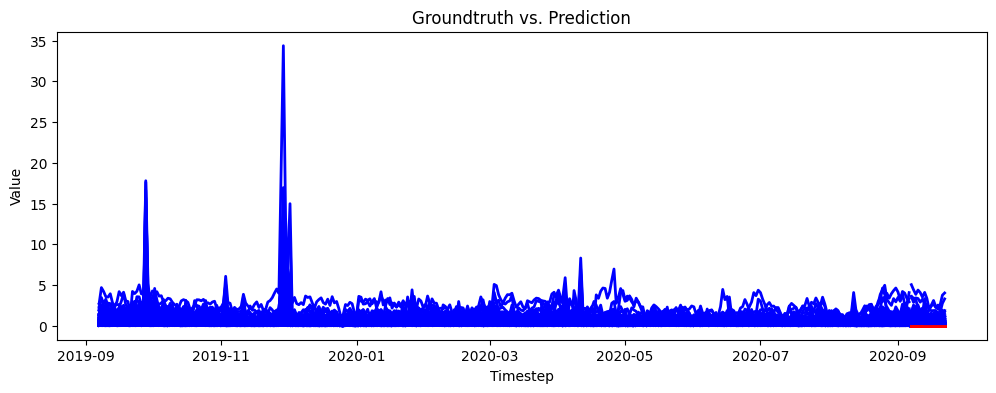

Training data shape: (366, 207)
Test data shape: (16, 207)
Prediction error for training step train: nan


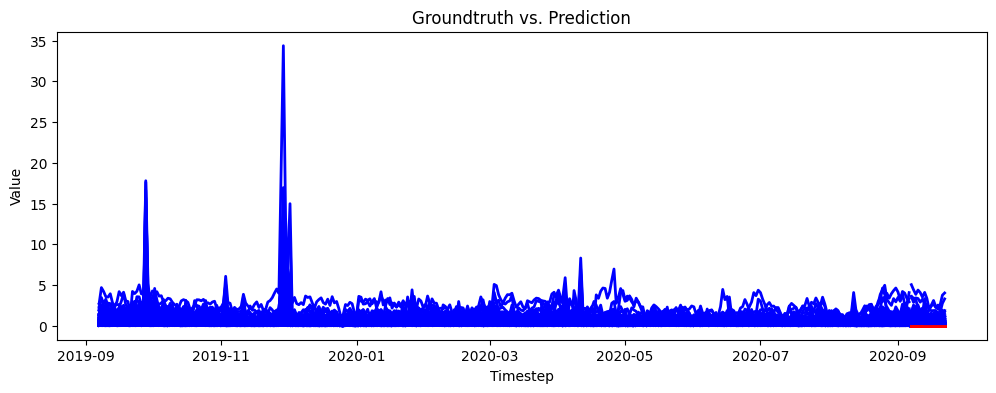

In [ ]:
for mode in ['full', 'partial']:
    df_in = df.copy()
    if mode == 'partial':
        df_in = df_in[:3]
    df_train = df[df['t_dat'] < dataset.val_timestamp]
    df_test = df[df['t_dat'] >= dataset.val_timestamp]

    train_data = df_train.drop(columns=['t_dat']).values.astype(np.float32)
    test_data = df_test.drop(columns=['t_dat']).values.astype(np.float32)
    print(f"Training data shape: {train_data.shape}")
    print(f"Test data shape: {test_data.shape}")

    # Convert to PyTorch tensors and move to GPU
    train_tensor = torch.tensor(train_data.T, dtype=torch.float32).to('cuda')
    test_tensor = torch.tensor(test_data.T, dtype=torch.float32).to('cuda')

    # Prepare inputs for the forecaster
    inputs = MaskedTimeseries(
        series=train_tensor,
        padding_mask=torch.full_like(train_tensor, True, dtype=torch.bool),
        id_mask=torch.zeros_like(train_tensor),
        timestamp_seconds=torch.zeros_like(train_tensor),
        time_interval_seconds=torch.full((1,), 60 * 60).to('cuda')
    )

    # Generate forecasts
    forecast = forecaster.forecast(inputs, prediction_length=test_tensor.shape[-1], num_samples=None, samples_per_batch=None)

    # Compute prediction errors
    error = torch.mean(
        torch.abs((forecast.mean.squeeze() - test_tensor) )
    ).item() # / (arr_tensor[:, -pred_len:] + epsilon)
    print(f"Prediction error for training step train: {error:.2f}")

    pred = forecast.mean.detach().cpu().numpy().squeeze()

    plt.figure(figsize=(12, 4))
    for i in range(train_data.shape[1]):
        plt.plot(df_train['t_dat'].values, train_data[:,i], label='Groundtruth (Training)', linewidth=2, color='blue')
        plt.plot(df_test['t_dat'].values, test_data[:,i], label='Groundtruth (Test)', linewidth=2, color='blue')
        plt.plot(df_test['t_dat'].values, pred[i, :], label='Prediction', linewidth=2, color='red')
    # plt.legend()
    plt.title("Groundtruth vs. Prediction")
    plt.xlabel("Timestep")
    plt.ylabel("Value")
    plt.show()


Detected breakpoints: [600]


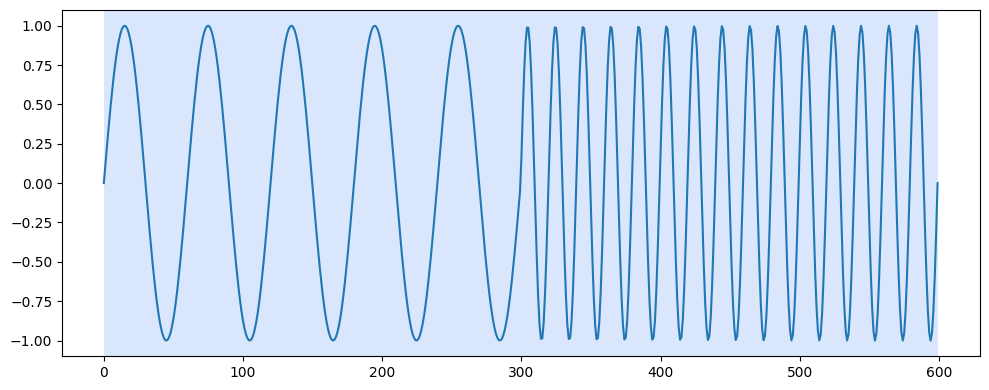

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt

# Simulate sinusoid with two frequency shifts
n = 600
t = np.linspace(0, 10, n)
sig = np.sin(2*np.pi*1*t)
sig[n//2:] = np.sin(2*np.pi*3*t[n//2:])  # frequency jump at halfway

# Detect change points using PELT + "rbf" cost
algo = rpt.Pelt(model="rbf", min_size=20, jump=5).fit(sig)
bkps = algo.predict(pen=10)
print("Detected breakpoints:", bkps)

# Display
rpt.display(sig, bkps, figsize=(10, 4))
plt.show()


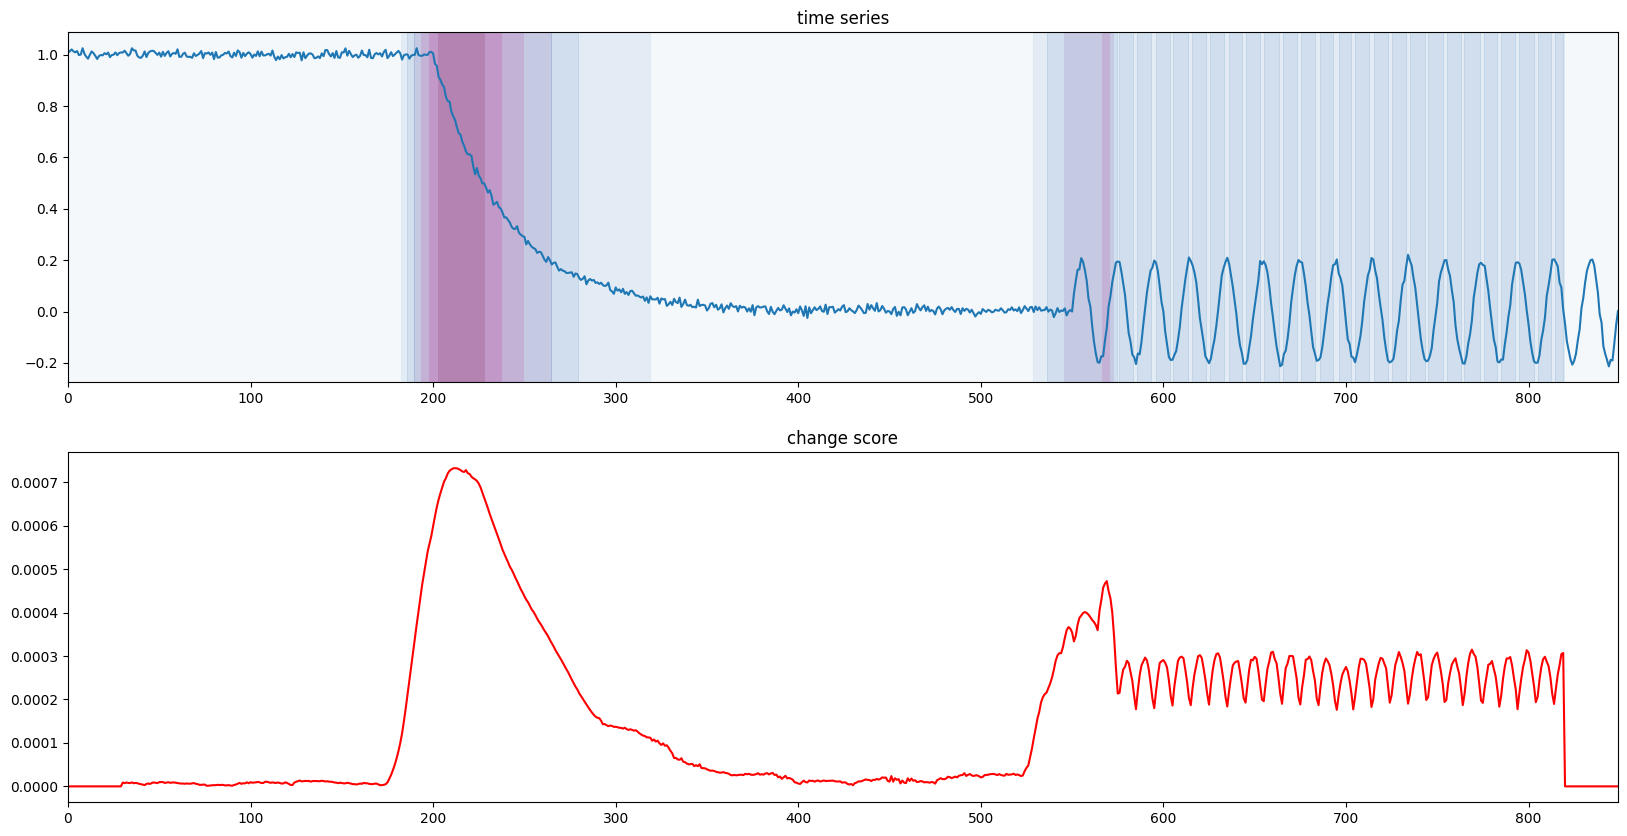

In [ ]:
from changepoynt.algorithms.esst import ESST
from changepoynt.visualization.score_plotting import plot_data_and_score
import numpy as np
import matplotlib.pyplot as plt

# simulate signal: steady → exponential decline → sine wave
steady_before = np.ones(200)
exp_signal = np.exp(-np.linspace(0, 5, 200))
steady_after = np.exp(-5) * np.ones(150)
sine_after = 0.2 * np.sin(np.linspace(0, 3*np.pi*10, 300))
signal = np.concatenate((steady_before, exp_signal, steady_after, sine_after))
signal += 0.01 * np.random.randn(signal.shape[0])

# Correct usage: passing window_length (e.g., 30)
detector = ESST(30)
scores = detector.transform(signal)

# Plot signal + change-point scoring
plot_data_and_score(signal, scores)
plt.show()


/tmp/ipykernel_519621/3538502506.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(boundaries) - 1)


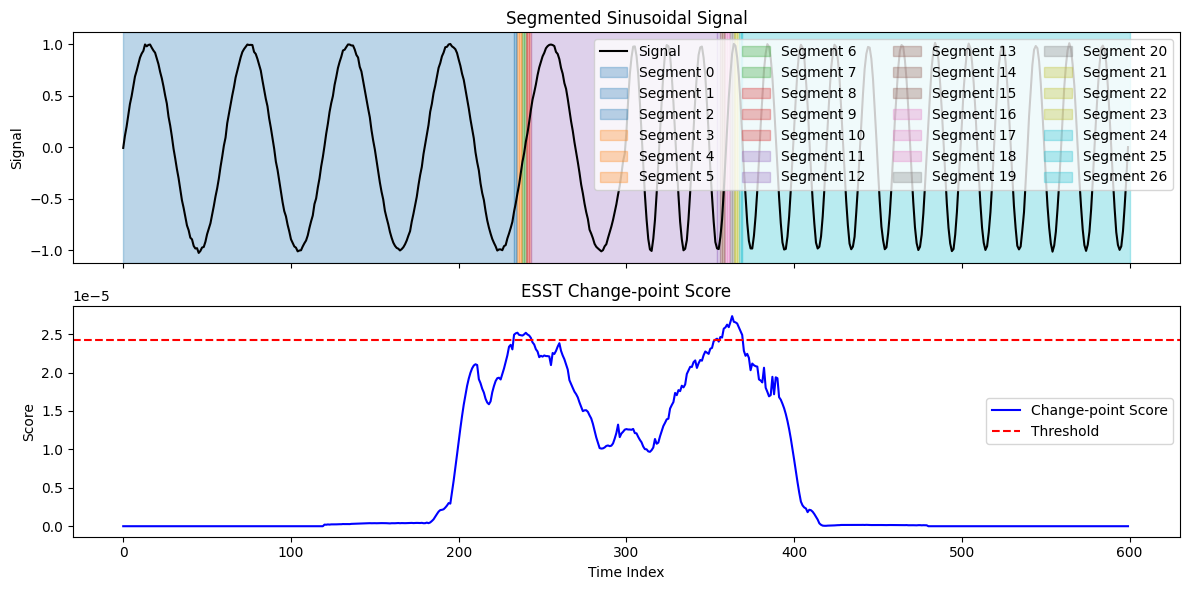

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from changepoynt.algorithms.esst import ESST

# --- Simulate sinusoidal signal with a frequency change ---
n = 600
t = np.linspace(0, 10, n)
signal = np.sin(2 * np.pi * 1 * t)
signal[n//2:] = np.sin(2 * np.pi * 3 * t[n//2:])
signal += 0.01 * np.random.randn(n)  # add small noise

# --- Run ESST detection ---
window_length = 120
detector = ESST(window_length)
scores = detector.transform(signal)

# --- Thresholding to detect change points ---
threshold = np.mean(scores) + 2 * np.std(scores)
change_points = np.where(scores > threshold)[0]

# Add beginning and end to get full segment boundaries
boundaries = [0] + change_points.tolist() + [len(signal)]

# --- Plot the results ---
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot signal with colored segments
axs[0].plot(signal, label='Signal', color='black')
cmap = plt.cm.get_cmap('tab10', len(boundaries) - 1)

for i in range(len(boundaries) - 1):
    start, end = boundaries[i], boundaries[i + 1]
    axs[0].axvspan(start, end, alpha=0.3, color=cmap(i), label=f'Segment {i}')

axs[0].set_ylabel("Signal")
axs[0].set_title("Segmented Sinusoidal Signal")
axs[0].legend(loc="upper right", ncol=4)

# Plot change-point score
axs[1].plot(scores, label='Change-point Score', color='blue')
axs[1].axhline(threshold, color='red', linestyle='--', label='Threshold')
axs[1].legend()
axs[1].set_ylabel("Score")
axs[1].set_xlabel("Time Index")
axs[1].set_title("ESST Change-point Score")

plt.tight_layout()
plt.show()
